In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

Softmax function:

In [57]:
def softmax(z):

  #Compute the softmax probabilities for a given input matrix.
  # ensure 2D
    z = np.atleast_2d(z)
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return probs

Softmax Test Case:
This test case checks that each row in the resulting softmax probabilities sums to 1, which is the fundamental property of softmax.

In [58]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")
print(softmax_output)

Softmax function passed the test case!
[[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]


Prediction Function:

In [59]:
def predict_softmax(X, W, b):

    #Predict the class labels for a set of samples using the trained softmax model
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    predicted_classes = np.argmax(y_pred, axis=1)
    return predicted_classes

Test Function for Prediction Function:

In [60]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


Loss Function

In [61]:
def loss_softmax(y_pred, y):

    #Compute the average cross-entropy loss.
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    n = y.shape[0]
    loss = -np.sum(y * np.log(y_pred)) / n
    return loss

Test case for Loss Function:

In [62]:
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

y_pred_correct = np.array([
    [0.9, 0.05, 0.05],
    [0.1, 0.85, 0.05],
    [0.05, 0.1, 0.85]
])

y_pred_incorrect = np.array([
    [0.05, 0.05, 0.9],
    [0.1, 0.05, 0.85],
    [0.85, 0.1, 0.05]
])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, but got "
    f"{loss_correct:.4f} >= {loss_incorrect:.4f}"
)

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


Cost Function

In [63]:
def cost_softmax(X, y, W, b):

    #Compute the average softmax regression cost over all samples
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    total_loss = loss_softmax(y_pred, y)
    return total_loss

Test Case for Cost Function:

In [64]:
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


Compute Gradients

In [65]:
def compute_gradient_softmax(X, y, W, b):

    #Compute gradients of the cost function w.r.t. W and b
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

Test case for compute_gradient function:

In [66]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


Implementing Gradient Descent:

In [67]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    #Perform gradient descent to optimize weights and biases
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

In [68]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Preparing Dataset:

In [69]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):

    #Reads the MNIST CSV file, splits into train/test sets, and plots one image per class.

    df = pd.read_csv('/content/drive/MyDrive/AI ML/Data/mnist_dataset.csv')

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    X = X / 255.0  # normalize to [0,1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

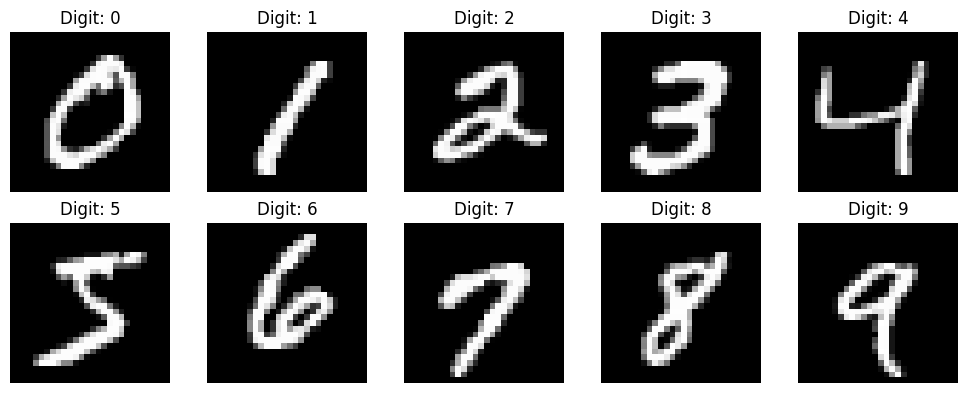

Move forward: Dimension of Feature Matrix X and label vector y matched.
Iteration 0: Cost = 2.220755
Iteration 100: Cost = 0.607962
Iteration 200: Cost = 0.489214
Iteration 300: Cost = 0.440220
Iteration 400: Cost = 0.411950
Iteration 500: Cost = 0.392978
Iteration 600: Cost = 0.379095
Iteration 700: Cost = 0.368349
Iteration 800: Cost = 0.359700
Iteration 900: Cost = 0.352535
Iteration 999: Cost = 0.346522


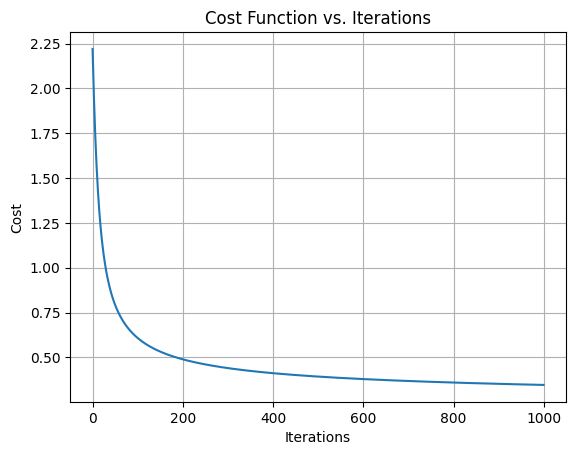

In [71]:
csv_file = "/content/drive/MyDrive/AI ML/Data/mnist_train.csv"

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)

assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]
c = y_train.shape[1]

np.random.seed(42)
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Evaluating the Model:

In [72]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.
    """
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

In [73]:
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Confusion Matrix:
[[1135    0    6    2    3   11    8    1   16    3]
 [   0 1294   10    8    1    5    3    3   22    2]
 [  10   24 1019   20   20    3   21   20   47    8]
 [   7    5   37 1072    0   34    7   16   34   14]
 [   3    5   11    2 1069    1    8    1    9   59]
 [  18   14    6   47   15  909   19    5   36   15]
 [  10    3    6    0   15   24 1118    0    8    0]
 [   9   21   22    5    9    3    1 1133    4   46]
 [   7   28   14   38    8   32    8    5 1014   16]
 [   6   11    3   20   37    6    1   36   10 1060]]
Precision: 0.9019
Recall: 0.9019
F1-Score: 0.9017


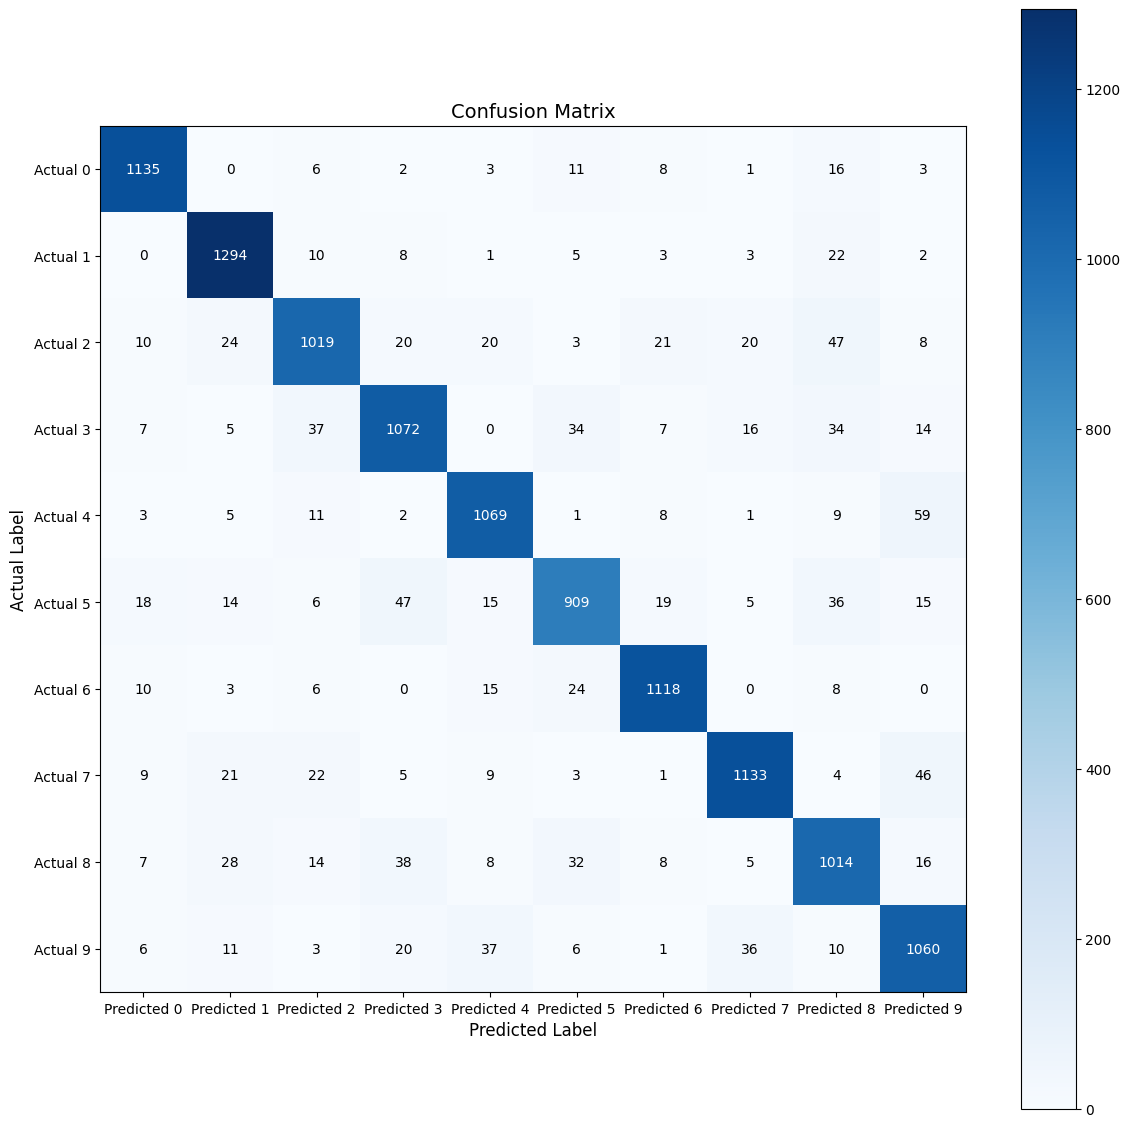

In [74]:
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

Linear separability and Logistic Regression

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [76]:
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

LogisticRegression()

In [77]:
# Generate non-linearly separable dataset
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.5,
    random_state=42
)

X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

LogisticRegression()

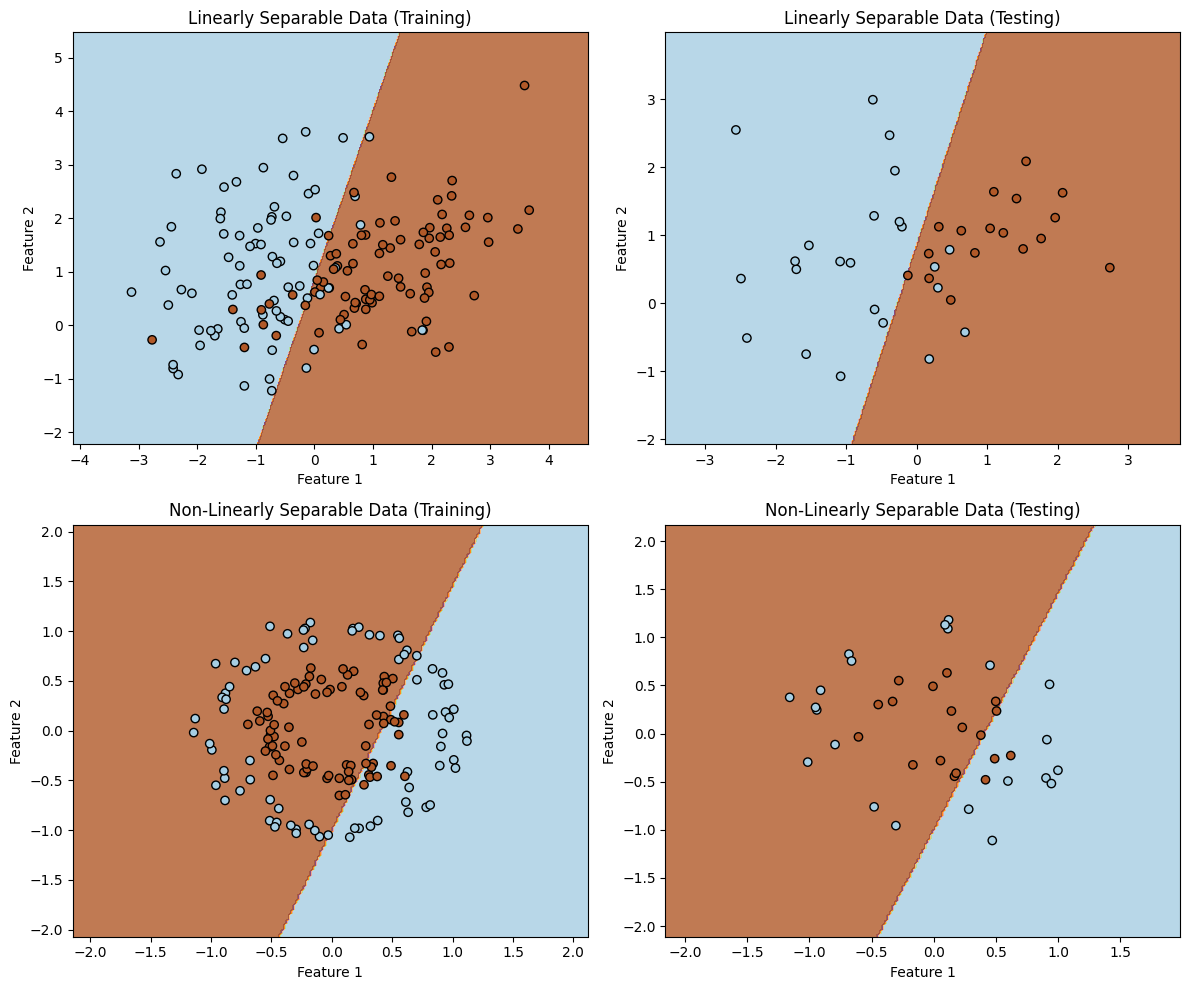

In [78]:
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'Linearly Separable Data (Testing)'
)

plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

Question 2: The output shows that logistic regression works well for linearly separable data, where classes can be divided by a straight line. The model correctly classifies most points in this case. However, for non-linear data, the model performs poorly because it cannot capture complex patterns. This shows that logistic regression is limited to linear decision boundaries.

Question 3: One challenge was understanding how softmax converts outputs into probabilities. Implementing the loss function and gradients correctly was also difficult at first. Handling matrix dimensions during calculations caused some confusion. Preparing and evaluating the dataset properly was another challenge.